<a href="https://colab.research.google.com/github/jhuarancca/ChiefAIOfficerProgram/blob/main/CAIO_Clase_2_Validaci%C3%B3n_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

📁 Por favor, sube tu archivo CSV


Saving retail_sales_2.csv to retail_sales_2.csv
✅ Archivo 'retail_sales_2.csv' cargado exitosamente!
📊 Datos cargados: 200 empleados, 5 columnas

📈 ANÁLISIS EXPLORATORIO DE DATOS
📐 Dimensiones: (200, 5)
🔤 Tipos de datos:
vendedor     object
monto       float64
fecha        object
tienda       object
region       object
dtype: object

👀 PRIMER VISTAZO A LOS DATOS
Primeras 5 filas:
  vendedor    monto   fecha    tienda region
0   Miguel  1592.42  24-Feb  Tienda C  Oeste
1    Carla   332.26  24-Sep  Tienda D   Este
2    Maria  4742.37  24-Jul  Tienda D   Este
3    Carla  1690.78  24-Jan  Tienda C  Oeste
4     Juan  2616.29  24-Apr  Tienda D   Este

Estadísticas descriptivas:
             monto
count   197.000000
mean   2380.089188
std    1309.009057
min     212.160000
25%    1405.310000
50%    2349.010000
75%    3427.990000
max    4943.000000

🔍 CALIDAD DE DATOS
Valores nulos por columna:
vendedor    0
monto       3
fecha       0
tienda      2
region      1
dtype: int64

⚠️  Columnas con 

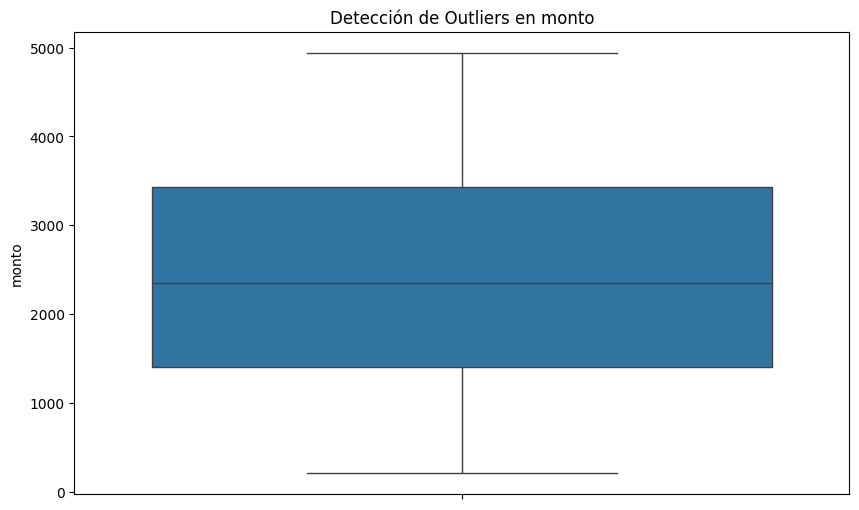

In [ ]:
# FUNCIÓN PARA CARGAR ARCHIVO
def cargar_archivo():
    print("📁 Por favor, sube tu archivo CSV")
    print("="*60)

    # Subir archivo
    uploaded = files.upload()

    if uploaded:
        file_name = list(uploaded.keys())[0]
        print(f"✅ Archivo '{file_name}' cargado exitosamente!")

        # Leer el archivo CSV
        try:
            df = pd.read_csv(io.BytesIO(uploaded[file_name]))
            print(f"📊 Datos cargados: {df.shape[0]} empleados, {df.shape[1]} columnas")
            return df
        except Exception as e:
            print(f"❌ Error al leer el archivo: {e}")
            return None
    else:
        print("❌ No se seleccionó ningún archivo")
        return None

# EJECUTAR LA FUNCIÓN PARA CARGAR DATOS
df = cargar_archivo()

# VERIFICAR QUE LOS DATOS SE CARGARON ANTES DE CONTINUAR
if df is not None:
    print("\n" + "="*60)
    print("📈 ANÁLISIS EXPLORATORIO DE DATOS")
    print("="*60)

    # Dimensiones y tipos de datos
    print(f"📐 Dimensiones: {df.shape}")
    print(f"🔤 Tipos de datos:\n{df.dtypes}")

    print("\n" + "="*40)
    print("👀 PRIMER VISTAZO A LOS DATOS")
    print("="*40)

    # Primer vistazo
    print("Primeras 5 filas:")
    print(df.head())

    print("\nEstadísticas descriptivas:")
    print(df.describe())

    print("\n" + "="*40)
    print("🔍 CALIDAD DE DATOS")
    print("="*40)

    # Valores nulos
    print("Valores nulos por columna:")
    null_count = df.isnull().sum()
    print(null_count)

    # Mostrar columnas con valores nulos
    if null_count.any():
        print(f"\n⚠️  Columnas con valores nulos: {list(null_count[null_count > 0].index)}")
    else:
        print("✅ No hay valores nulos en el dataset")

    # Duplicados
    duplicates = df.duplicated().sum()
    print(f"\n📝 Registros duplicados: {duplicates}")

    if duplicates > 0:
        print("⚠️  Se recomienda limpiar los registros duplicados")
    else:
        print("✅ No hay registros duplicados")

    print("\n" + "="*40)
    print("📊 ANÁLISIS DE OUTLIERS")
    print("="*40)

    # Identificar columnas numéricas para análisis de outliers
    numeric_columns = df.select_dtypes(include=[np.number]).columns

    if len(numeric_columns) > 0:
        print(f"Columnas numéricas encontradas: {list(numeric_columns)}")

        # Verificar si existe la columna 'ventas'
        if 'ventas' in df.columns:
            plt.figure(figsize=(10, 6))
            sns.boxplot(data=df, y='ventas')
            plt.title('Detección de Outliers en Ventas')
            plt.show()

            # Estadísticas adicionales de ventas
            print(f"\n📊 Estadísticas de ventas:")
            print(f"   Mínimo: {df['ventas'].min():.2f}")
            print(f"   Máximo: {df['ventas'].max():.2f}")
            print(f"   Mediana: {df['ventas'].median():.2f}")
            print(f"   Promedio: {df['ventas'].mean():.2f}")
        else:
            print("❌ No se encontró la columna 'ventas'")
            print("Columnas disponibles:", list(df.columns))

            # Mostrar boxplot de la primera columna numérica disponible
            primera_numerica = numeric_columns[0]
            plt.figure(figsize=(10, 6))
            sns.boxplot(data=df, y=primera_numerica)
            plt.title(f'Detección de Outliers en {primera_numerica}')
            plt.show()
    else:
        print("❌ No se encontraron columnas numéricas en el dataset")

else:
    print("❌ No se pudo cargar el dataset. Por favor, intenta nuevamente.")



📅 EVOLUCIÓN TEMPORAL DE VENTAS
🔍 Examinando formato de fechas...
Primeras 5 fechas: ['24-Feb', '24-Sep', '24-Jul', '24-Jan', '24-Apr']
Tipo de dato actual: object
📅 Detectadas fechas sin año, asignando año actual...
✅ Fechas convertidas exitosamente
Ejemplo de fechas convertidas: [Timestamp('2026-02-24 00:00:00'), Timestamp('2026-09-24 00:00:00'), Timestamp('2026-07-24 00:00:00'), Timestamp('2026-01-24 00:00:00'), Timestamp('2026-04-24 00:00:00')]


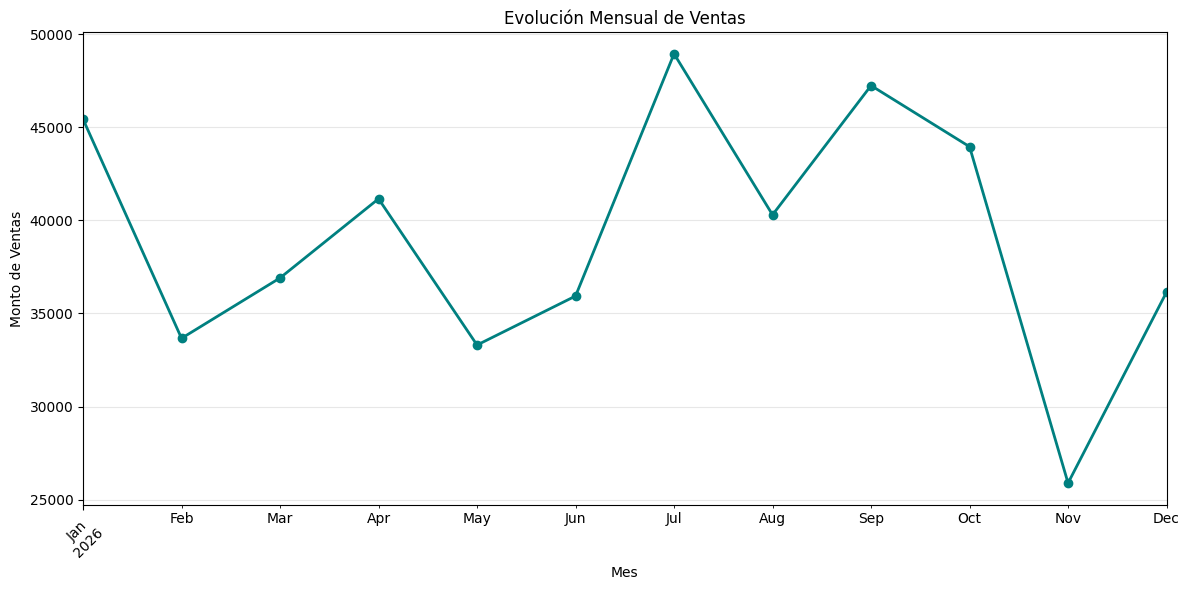


📊 ESTADÍSTICAS DE LA SERIE TEMPORAL:
   Período analizado: 12 meses
   Ventas totales: $468,877.57
   Promedio mensual: $39,073.13
   Mejor mes: 2026-07 ($48,946.82)
   Tendencia: 📉 Decreciente (-20.4%)


In [ ]:
# EVOLUCIÓN TEMPORAL DE VENTAS
print("\n\n📅 EVOLUCIÓN TEMPORAL DE VENTAS")

# Primero, examinemos cómo se ven las fechas
print("🔍 Examinando formato de fechas...")
print("Primeras 5 fechas:", df['fecha'].head().tolist())
print("Tipo de dato actual:", df['fecha'].dtype)

# Intentar diferentes métodos de conversión
try:
    # Método 1: Especificar formato manualmente si es conocido
    df['fecha'] = pd.to_datetime(df['fecha'], format='%d-%b', errors='coerce')

    # Si falla el método 1, intentar método 2
    if df['fecha'].isnull().all():
        print("⚠️  Método 1 falló, intentando método 2...")
        df['fecha'] = pd.to_datetime(df['fecha'], infer_datetime_format=True, errors='coerce')

    # Verificar si la conversión fue exitosa
    null_count = df['fecha'].isnull().sum()
    if null_count > 0:
        print(f"⚠️  {null_count} fechas no pudieron convertirse y se establecieron como NaT")

    # Si tenemos años faltantes, asumir un año (por ejemplo, el año actual)
    if df['fecha'].notna().any():
        # Verificar si tenemos solo día y mes (sin año)
        sample_date = df['fecha'].dropna().iloc[0]
        if sample_date.year == 1900:  # Pandas asigna 1900 por defecto para fechas sin año
            print("📅 Detectadas fechas sin año, asignando año actual...")
            current_year = pd.Timestamp.now().year
            df['fecha'] = df['fecha'].apply(lambda x: x.replace(year=current_year) if pd.notna(x) else x)

    print("✅ Fechas convertidas exitosamente")
    print("Ejemplo de fechas convertidas:", df['fecha'].head().tolist())

except Exception as e:
    print(f"❌ Error en conversión de fechas: {e}")
    print("🔄 Intentando método alternativo...")

    # Método alternativo: extraer día y mes manualmente
    try:
        # Asumir formato "24-Feb" y asignar año actual
        current_year = pd.Timestamp.now().year

        def parse_custom_date(date_str):
            try:
                if pd.isna(date_str):
                    return pd.NaT
                # Para formato "24-Feb"
                day = int(date_str.split('-')[0])
                month_str = date_str.split('-')[1]
                month_map = {
                    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
                    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
                }
                month = month_map.get(month_str, 1)
                return pd.Timestamp(year=current_year, month=month, day=day)
            except:
                return pd.NaT

        df['fecha'] = df['fecha'].apply(parse_custom_date)
        print("✅ Fechas convertidas con método alternativo")

    except Exception as e2:
        print(f"❌ Todos los métodos fallaron: {e2}")
        print("📊 Continuando con análisis no temporal...")
        df['fecha'] = pd.NaT  # Establecer como no disponibles

# SOLO si tenemos fechas válidas, proceder con el análisis temporal
if df['fecha'].notna().any():
    # Agrupar por mes
    ventas_mensuales = df.groupby(df['fecha'].dt.to_period('M'))['monto'].sum()

    if len(ventas_mensuales) > 0:
        plt.figure(figsize=(12, 6))
        ventas_mensuales.plot(marker='o', linewidth=2, markersize=6, color='teal')
        plt.title('Evolución Mensual de Ventas')
        plt.xlabel('Mes')
        plt.ylabel('Monto de Ventas')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Estadísticas de la serie temporal
        print(f"\n📊 ESTADÍSTICAS DE LA SERIE TEMPORAL:")
        print(f"   Período analizado: {len(ventas_mensuales)} meses")
        print(f"   Ventas totales: ${ventas_mensuales.sum():,.2f}")
        print(f"   Promedio mensual: ${ventas_mensuales.mean():,.2f}")
        print(f"   Mejor mes: {ventas_mensuales.idxmax()} (${ventas_mensuales.max():,.2f})")

        # Calcular tendencia
        if len(ventas_mensuales) > 1:
            primer_valor = ventas_mensuales.iloc[0]
            ultimo_valor = ventas_mensuales.iloc[-1]
            cambio_porcentual = ((ultimo_valor - primer_valor) / primer_valor) * 100

            tendencia = "📈 Creciente" if ultimo_valor > primer_valor else "📉 Decreciente"
            print(f"   Tendencia: {tendencia} ({cambio_porcentual:+.1f}%)")
    else:
        print("❌ No hay suficientes datos temporales para el análisis")
else:
    print("❌ No hay fechas válidas para el análisis temporal")

    # ANÁLISIS ALTERNATIVO: Ventas por orden de registro
    print("\n📈 ANÁLISIS ALTERNATIVO: Ventas por Orden de Registro")

    # Crear un índice secuencial como proxy del tiempo
    df_ordenado = df.reset_index().rename(columns={'index': 'orden'})
    df_ordenado['orden_grupo'] = (df_ordenado['orden'] // 10) + 1  # Agrupar cada 10 registros

    ventas_por_grupo = df_ordenado.groupby('orden_grupo')['monto'].sum()

    plt.figure(figsize=(12, 6))
    ventas_por_grupo.plot(marker='o', linewidth=2, markersize=4, color='orange')
    plt.title('Evolución de Ventas por Grupos de Registros')
    plt.xlabel('Grupo de Registros (cada 10 transacciones)')
    plt.ylabel('Monto de Ventas')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# MATRIZ DE CORRELACIÓN CON TUS VARIABLES
print("\n" + "="*50)
print("🔗 MATRIZ DE CORRELACIÓN")
print("="*50)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

print(f"Variables numéricas encontradas: {list(numeric_cols)}")

if len(numeric_cols) > 1:
    # Calcular matriz de correlación
    corr_matrix = df[numeric_cols].corr()

    # Crear el heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix,
                annot=True,
                cmap='coolwarm',
                center=0,
                fmt='.2f',
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8})

    plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Análisis interpretativo de correlaciones
    print("\n📊 INTERPRETACIÓN DE CORRELACIONES:")

    # Encontrar correlaciones fuertes (positivas y negativas)
    strong_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.5:  # Correlación fuerte
                strong_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_value))

    if strong_corr:
        print("🔍 Correlaciones fuertes encontradas:")
        for var1, var2, corr in strong_corr:
            direction = "positiva" if corr > 0 else "negativa"
            print(f"   • {var1} ↔ {var2}: {corr:.2f} ({direction})")
    else:
        print("   No se encontraron correlaciones fuertes (|r| > 0.5)")

    # Correlación específica con 'monto' (si existe)
    if 'monto' in numeric_cols:
        print(f"\n💰 CORRELACIONES CON MONTO:")
        monto_correlations = corr_matrix['monto'].sort_values(ascending=False)
        for var, corr in monto_correlations.items():
            if var != 'monto':  # Excluir correlación consigo mismo
                strength = "fuerte" if abs(corr) > 0.5 else "moderada" if abs(corr) > 0.3 else "débil"
                direction = "positiva" if corr > 0 else "negativa"
                print(f"   • {var}: {corr:.2f} ({strength}, {direction})")

else:
    print("❌ No hay suficientes variables numéricas para calcular correlaciones")
    print(f"   Variables numéricas encontradas: {len(numeric_cols)}")

    # Mostrar variables disponibles para contexto
    print(f"\n📋 TODAS LAS VARIABLES DISPONIBLES:")
    for col in df.columns:
        dtype = df[col].dtype
        print(f"   • {col}: {dtype}")


🔗 MATRIZ DE CORRELACIÓN
Variables numéricas encontradas: ['monto']
❌ No hay suficientes variables numéricas para calcular correlaciones
   Variables numéricas encontradas: 1

📋 TODAS LAS VARIABLES DISPONIBLES:
   • vendedor: object
   • monto: float64
   • fecha: datetime64[ns]
   • tienda: object
   • region: object
